**1. Configuración del Entorno e Instalación**



In [1]:
# 1. Importar librerías

# Instalar PyTorch con soporte GPU (CUDA) y ultralytics
!pip uninstall -y ultralytics torch torchvision torchaudio -q
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q
!pip install ultralytics -q

import os
import glob
import random
import pandas as pd
import shutil
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO

# Montar Google Drive (donde está el dataset)
from google.colab import drive
drive.mount('/content/drive')

SEED = 42
random.seed(SEED)

print("Librerías cargadas correctamente")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 108.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 108.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 87.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 56.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 109.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

**2. Parámetros del entrenamiento**


In [2]:
RUTA_YAML       = "/content/drive/MyDrive/BrainTumorMRIDataset/Processed_Dataset/dataset.yaml"
RUTA_RESULTADOS = "/content/drive/MyDrive/BrainTumorMRIDataset/outputs/Resultados_YOLOv8"

EPOCHS     = 80
IMG_SIZE   = 832   # antes 640
BATCH_SIZE = 8     # antes 16, necesario para compensar la memoria
PATIENCE   = 10    # antes era 10, necesario para que el modelo tenga tiempo de aprender
MODELO     = "yolov8s.pt"

NOMBRES_CLASES = ['Glioma', 'Meningioma', 'Pituitary']
COLORES_CLASES = {0: 'red', 1: 'blue', 2: 'green'}

device = 0 if torch.cuda.is_available() else 'cpu'

os.makedirs(RUTA_RESULTADOS, exist_ok=True)
print("=" * 45)
print("   PARÁMETROS DEL ENTRENAMIENTO")
print("=" * 45)
print(f"  YAML       : {RUTA_YAML}")
print(f"  Resultados : {RUTA_RESULTADOS}")
print(f"  Épocas     : {EPOCHS}")
print(f"  Img size   : {IMG_SIZE}")
print(f"  Batch      : {BATCH_SIZE}")
print(f"  Modelo     : {MODELO}")
print(f"  Dispositivo: {'GPU' if device == 0 else 'CPU'}")
print("=" * 45)
print("Parámetros listos")

   PARÁMETROS DEL ENTRENAMIENTO
  YAML       : /content/drive/MyDrive/BrainTumorMRIDataset/Processed_Dataset/dataset.yaml
  Resultados : /content/drive/MyDrive/BrainTumorMRIDataset/outputs/Resultados_YOLOv8
  Épocas     : 80
  Img size   : 832
  Batch      : 8
  Modelo     : yolov8s.pt
  Dispositivo: GPU
Parámetros listos


**3. Limpiar resultados anteriores**

In [3]:
if os.path.exists(RUTA_RESULTADOS):
    shutil.rmtree(RUTA_RESULTADOS)
    print("Resultados anteriores eliminados")
else:
    print("No había resultados previos")

os.makedirs(RUTA_RESULTADOS, exist_ok=True)
print("Listo para entrenar")

Resultados anteriores eliminados
Listo para entrenar


**4. Cargar modelo YOLOv8**



In [4]:
model = YOLO(MODELO)

print(f"Modelo '{MODELO}' cargado")
print(f"Tipo: {type(model)}")

Modelo 'yolov8s.pt' cargado
Tipo: <class 'ultralytics.models.yolo.model.YOLO'>


**5. Entrenamiento**



In [5]:
resultados = model.train(
    data     = RUTA_YAML,
    epochs   = EPOCHS,
    imgsz    = IMG_SIZE,
    batch    = BATCH_SIZE,
    device   = device,
    project  = RUTA_RESULTADOS,
    name     = MODELO,
    exist_ok = True,
    patience = PATIENCE,
    seed     = 42,
    verbose  = True,
    box      = 9.0,
    dfl      = 2.0,
    lr0      = 0.001,
    cos_lr   = True
)

print("Entrenamiento finalizado")

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=9.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/BrainTumorMRIDataset/Processed_Dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=2.0, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=832, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s.pt, nbs=64, nms=False, opset=None, optimize=False,

**6. Cargar el mejor modelo**

In [7]:
ruta_best = os.path.join(RUTA_RESULTADOS, MODELO, "weights", "best.pt")
model = YOLO(ruta_best)

print(f"Mejor modelo cargado desde:")
print(f"  {ruta_best}")

Mejor modelo cargado desde:
  /content/drive/MyDrive/BrainTumorMRIDataset/outputs/Resultados_YOLOv8/yolov8s.pt/weights/best.pt


**7.  Evaluación del modelo**



**7.1 Cálculo de Métricas**

In [8]:
metricas = model.val(
    data     = RUTA_YAML,
    split    = "test",
    device   = device,
    project  = RUTA_RESULTADOS,
    name     = "modelo",
    exist_ok = True,
)

# Guardar métricas globales en CSV y texto
os.makedirs(os.path.join(RUTA_RESULTADOS, 'metrics'), exist_ok=True)

metricas_globales = {
    'Precision': round(metricas.box.mp, 4),
    'Recall': round(metricas.box.mr, 4),
    'mAP@0.5': round(metricas.box.map50, 4),
    'mAP@0.5:0.95': round(metricas.box.map, 4),
}

with open(os.path.join(RUTA_RESULTADOS, 'metrics', 'metrics_summary.txt'), 'w', encoding='utf-8') as f:
    for k, v in metricas_globales.items():
        f.write(f'{k}: {v}\n')

pd.DataFrame([metricas_globales]).to_csv(os.path.join(RUTA_RESULTADOS, 'metrics', 'metrics_summary.csv'), index=False)

df_global = pd.DataFrame({
    "Métrica": ["Precisión", "Recall", "mAP@0.5", "mAP@0.5:0.95"],
    "Valor"  : [
        round(metricas.box.mp,    4),
        round(metricas.box.mr,    4),
        round(metricas.box.map50, 4),
        round(metricas.box.map,   4)
    ]
})

df_clases = pd.DataFrame({
    "Clase"       : NOMBRES_CLASES,
    "Precisión"   : [round(metricas.box.class_result(i)[0], 4) for i in range(len(NOMBRES_CLASES))],
    "Recall"      : [round(metricas.box.class_result(i)[1], 4) for i in range(len(NOMBRES_CLASES))],
    "mAP@0.5"     : [round(metricas.box.class_result(i)[2], 4) for i in range(len(NOMBRES_CLASES))],
    "mAP@0.5:0.95": [round(metricas.box.class_result(i)[3], 4) for i in range(len(NOMBRES_CLASES))]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 2))
for ax in axes:
    ax.axis("off")

axes[0].set_title("Métricas globales", fontweight="bold", pad=10)
t1 = axes[0].table(cellText=df_global.values, colLabels=df_global.columns, cellLoc="center", loc="center")
t1.auto_set_font_size(False)
t1.set_fontsize(11)
t1.scale(1.4, 1.8)

axes[1].set_title("mAP@0.5 por clase", fontweight="bold", pad=10)
t2 = axes[1].table(cellText=df_clases.values, colLabels=df_clases.columns, cellLoc="center", loc="center")
t2.auto_set_font_size(False)
t2.set_fontsize(11)
t2.scale(1.4, 1.8)

plt.suptitle("Resultados YOLOv8 — conjunto de test", fontsize=13, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_RESULTADOS, 'metrics', 'metricas_resumen.png'), dpi=300, bbox_inches='tight')
plt.close(fig)
print("Métricas guardadas en la carpeta de resultados")

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 2.3±1.5 ms, read: 0.2±0.1 MB/s, size: 150.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/BrainTumorMRIDataset/Processed_Dataset/labels/test... 379 images, 49 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 379/379 2.9it/s 2:12
val: New cache created: /content/drive/MyDrive/BrainTumorMRIDataset/Processed_Dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 2.2it/s 10.9s
                   all        379        330      0.795      0.761      0.828       0.55
                Glioma         77         77      0.673      0.688      0.735      0.516
            Meningiom

**7.2 Cálculo del IoU promedio en el conjunto de test**

In [9]:
# --- Función 1: convertir formato YOLO a xyxy ---
def yolo_a_xyxy(x_centro, y_centro, ancho, alto, img_w, img_h):
    xmin = (x_centro - ancho / 2) * img_w
    ymin = (y_centro - alto / 2) * img_h
    xmax = (x_centro + ancho / 2) * img_w
    ymax = (y_centro + alto / 2) * img_h
    return [xmin, ymin, xmax, ymax]

# --- Función 2: calcular IoU entre dos cajas ---
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0:
        return 0.0
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    return interArea / float(boxAArea + boxBArea - interArea)

# --- Bucle principal: calcular IoU promedio en el test set ---
from PIL import Image
import os
import numpy as np

ruta_test_imgs   = "/content/drive/MyDrive/BrainTumorMRIDataset/Processed_Dataset/images/test"
ruta_test_labels = "/content/drive/MyDrive/BrainTumorMRIDataset/Processed_Dataset/labels/test"

ious_yolo = []

for archivo_txt in sorted(os.listdir(ruta_test_labels)):
    if not archivo_txt.endswith('.txt'):
        continue

    nombre_base = archivo_txt.replace('.txt', '')

    ruta_img = None
    for ext in ['.jpg', '.JPG', '.png', '.jpeg']:
        candidato = os.path.join(ruta_test_imgs, nombre_base + ext)
        if os.path.exists(candidato):
            ruta_img = candidato
            break

    if ruta_img is None:
        continue

    img = Image.open(ruta_img)
    img_w, img_h = img.size

    gt_boxes = []
    ruta_txt = os.path.join(ruta_test_labels, archivo_txt)
    with open(ruta_txt, 'r') as f:
        for linea in f.readlines():
            partes = linea.strip().split()
            if len(partes) == 0:
                continue
            _, xc, yc, w, h = map(float, partes)
            gt_boxes.append(yolo_a_xyxy(xc, yc, w, h, img_w, img_h))

    if len(gt_boxes) == 0:
        continue

    pred = model.predict(source=ruta_img, device=device, conf=0.25, save=False, verbose=False)
    pred_boxes = pred[0].boxes.xyxy.cpu().numpy()

    if len(pred_boxes) == 0:
        continue

    for p_box in pred_boxes:
        max_iou = 0.0
        for g_box in gt_boxes:
            iou_actual = compute_iou(p_box, g_box)
            if iou_actual > max_iou:
                max_iou = iou_actual
        ious_yolo.append(max_iou)

mean_iou_yolo = np.mean(ious_yolo) if len(ious_yolo) > 0 else 0.0
print(f"IoU promedio (YOLOv8) sobre el test set: {mean_iou_yolo:.4f}")

IoU promedio (YOLOv8) sobre el test set: 0.7553


**7.3 Gráficas**

Resultados guardados en: /content/drive/MyDrive/BrainTumorMRIDataset/outputs/Resultados_YOLOv8/yolov8s.pt


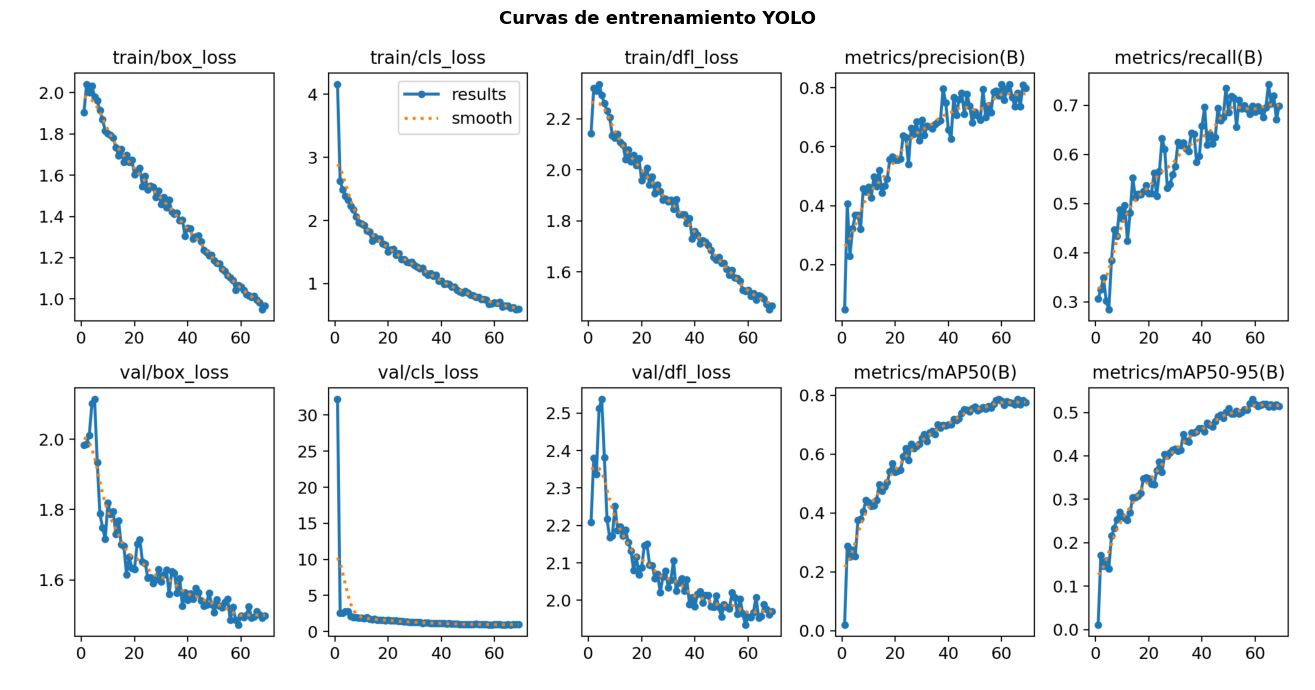

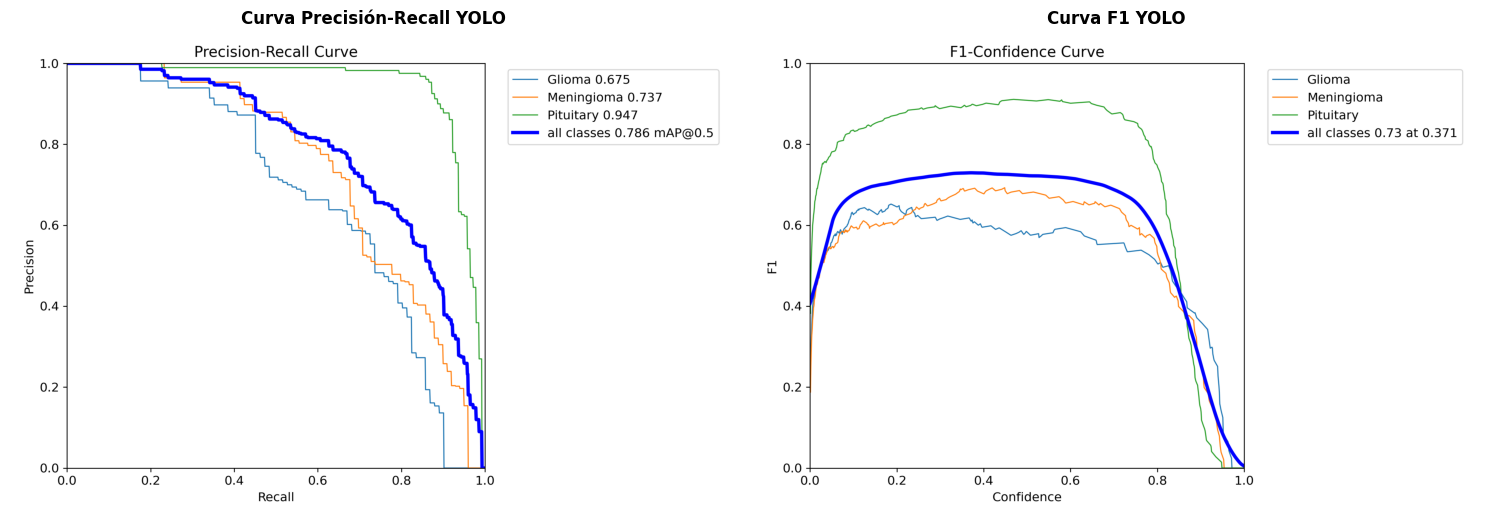

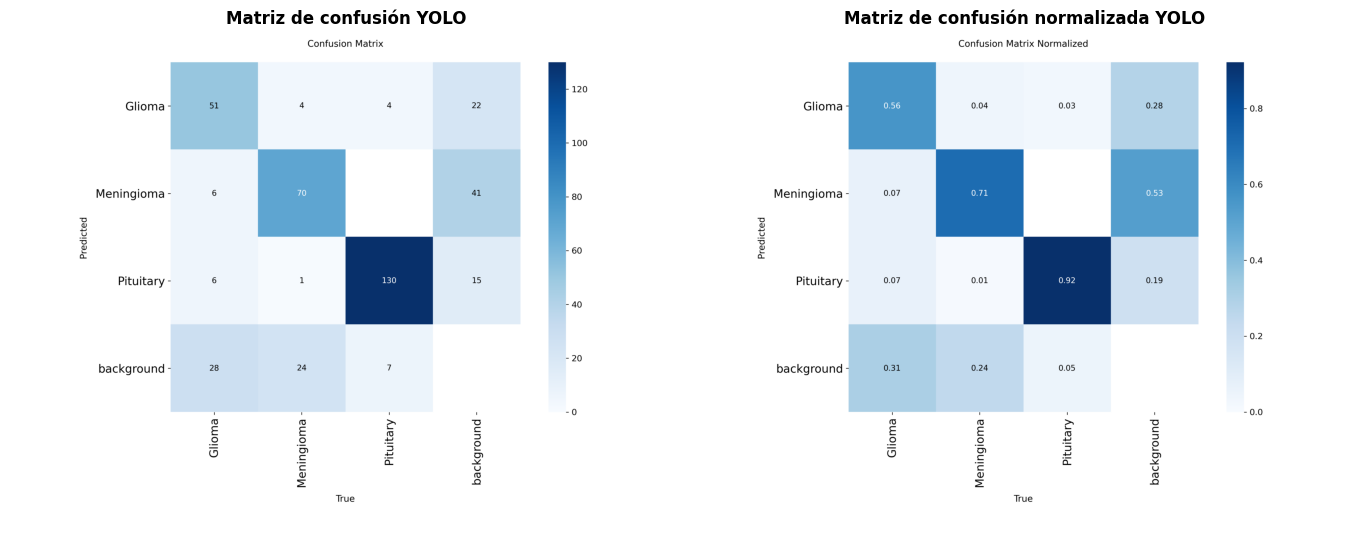

In [10]:
carpeta = str(resultados.save_dir)
print(f"Resultados guardados en: {carpeta}")

ANCHO = 18
ALTO  = 7

# Curvas de entrenamiento
img = plt.imread(os.path.join(carpeta, "results.png"))
fig, ax = plt.subplots(1, 1, figsize=(ANCHO, ALTO))
ax.imshow(img)
ax.set_title("Curvas de entrenamiento YOLO", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

# Curvas de precisión y F1
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, nombre, titulo in zip(
    axes,
    ["BoxPR_curve.png", "BoxF1_curve.png"],
    ["Curva Precisión-Recall YOLO", "Curva F1 YOLO"]
):
    img = plt.imread(os.path.join(carpeta, nombre))
    ax.imshow(img)
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.axis("off")
plt.subplots_adjust(wspace=0.05)
plt.tight_layout()
plt.show()

# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, nombre, titulo in zip(
    axes,
    ["confusion_matrix.png", "confusion_matrix_normalized.png"],
    ["Matriz de confusión YOLO", "Matriz de confusión normalizada YOLO"]
):
    img = plt.imread(os.path.join(carpeta, nombre))
    ax.imshow(img)
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.axis("off")
plt.subplots_adjust(left=0.0, right=0.75, wspace=0.01)
plt.show()

**8.  Predicciones sobre imágenes de test**

In [11]:
ruta_test_imgs   = "/content/drive/MyDrive/BrainTumorMRIDataset/Processed_Dataset/images/test"
ruta_test_labels = "/content/drive/MyDrive/BrainTumorMRIDataset/Processed_Dataset/labels/test"

imagen_por_clase = {}

for archivo_txt in sorted(os.listdir(ruta_test_labels)):
    if not archivo_txt.endswith('.txt'):
        continue
    ruta_txt = os.path.join(ruta_test_labels, archivo_txt)
    with open(ruta_txt, 'r') as f:
        lineas = f.readlines()
    clases_en_imagen = set(int(l.split()[0]) for l in lineas if l.strip())
    for id_clase in clases_en_imagen:
        if id_clase not in imagen_por_clase:
            nombre_base = archivo_txt.replace('.txt', '')
            for ext in ['.jpg', '.JPG', '.png', '.jpeg']:
                candidato = nombre_base + ext
                if os.path.exists(os.path.join(ruta_test_imgs, candidato)):
                    imagen_por_clase[id_clase] = candidato
                    break
    if len(imagen_por_clase) == len(NOMBRES_CLASES):
        break

print("Imágenes seleccionadas (una por clase):")
for id_clase, nombre in sorted(imagen_por_clase.items()):
    print(f"  Clase {id_clase} — {NOMBRES_CLASES[id_clase]}: {nombre}")

predictions_dir = os.path.join(RUTA_RESULTADOS, 'predictions')
os.makedirs(predictions_dir, exist_ok=True)

fig, axes = plt.subplots(1, len(imagen_por_clase), figsize=(6 * len(imagen_por_clase), 7))
if len(imagen_por_clase) == 1:
    axes = [axes]

for ax, (id_clase, nombre_img) in zip(axes, sorted(imagen_por_clase.items())):
    ruta_img = os.path.join(ruta_test_imgs, nombre_img)

    pred = model.predict(source=ruta_img, device=device, conf=0.25, save=False, verbose=False)

    img = Image.open(ruta_img)
    ax.imshow(img)
    ax.set_title(f"GT: {NOMBRES_CLASES[id_clase]}\n{nombre_img}", fontsize=9, fontweight="bold")
    ax.axis("off")

    boxes = pred[0].boxes
    if boxes is not None and len(boxes) > 0:
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cls   = int(box.cls[0])
            conf  = float(box.conf[0])
            color = COLORES_CLASES.get(cls, 'white')

            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, f"{NOMBRES_CLASES[cls]}  {conf:.2f}", color=color, fontsize=7, fontweight='bold',
                     bbox=dict(facecolor='black', alpha=0.4, pad=1))
    else:
        ax.text(0.5, 0.05, "Sin detecciones", transform=ax.transAxes, ha='center', color='yellow', fontsize=9,
                 bbox=dict(facecolor='black', alpha=0.6, pad=3))

plt.suptitle("Predicciones YOLOv8s — una imagen por clase (test)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(predictions_dir, 'predicciones_test.png'), dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"Predicciones visualizadas y guardadas en: {predictions_dir}")

Imágenes seleccionadas (una por clase):
  Clase 0 — Glioma: test_00003.jpg
  Clase 1 — Meningioma: test_00004.jpg
  Clase 2 — Pituitary: test_00000.jpg
Predicciones visualizadas y guardadas en: /content/drive/MyDrive/BrainTumorMRIDataset/outputs/Resultados_YOLOv8/predictions


**9. Exportación del Modelo**


In [12]:
# ── 10. Exportación del modelo ───────────────────────────

ruta_export = model.export(format="onnx")

export_dir = os.path.join(RUTA_RESULTADOS, 'exports')
os.makedirs(export_dir, exist_ok=True)

if os.path.exists(ruta_export):
    destino = os.path.join(export_dir, os.path.basename(ruta_export))
    os.replace(ruta_export, destino)
    ruta_export = destino

print(f"Modelo exportado correctamente a formato ONNX")
print(f"Ubicación: {ruta_export}")

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.5.1+cu121 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/BrainTumorMRIDataset/outputs/Resultados_YOLOv8/yolov8s.pt/weights/best.pt' with input shape (1, 3, 832, 832) BCHW and output shape(s) (1, 7, 14196) (21.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 348ms
Prepared 4 packages in 1.90s
Installed 4 packages in 272ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 19...
ONNX: slimming with onnxslim 0.1.94...
ONNX: 